# Import Libraries and read file

In [1]:
import pandas as pd
import os

low_x0, low_y0, low_w, low_h, bottom_z, top_z = -500, -500, 1000, 1000, -500, 500

def get_velz_dens(x_range, y_range, z_range):
    # read a 3D grid of velz and density array
    velz = obj["flash", "velz"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value        
    dens = obj["flash", "dens"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('g/cm**3').value        
    temp = obj["flash", "temp"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('K').value 

    print(f"obj.shape: {obj['flash', 'velz'].shape}")
    print("x, y, z ranges: ", x_range, y_range, z_range)
    print(f"velz.shape: {velz.shape}\tdens.shape: {dens.shape}\n\n")      
     

    dz = obj['flash', 'dz'][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('cm').value
    mp = yt.physical_constants.mp.value # proton mass

    # calculate the density as column density
    coldens = dens * dz / (1.4 * mp)

    return velz, coldens, temp

def get_velx_vely(x_range, y_range, z_range):
    # read a 3D grid of vely and density array
    vely = obj["flash", "vely"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value
    velx = obj["flash", "velx"][x_range[0] : x_range[1], y_range[0] : y_range[1], z_range[0] : z_range[1]].to('km/s').value
    
    print(f"velx.shape: {velx.shape}\tvely.shape: {vely.shape}\n\n")      
    
    return velx, vely

# convert seconds to Megayears
def seconds_to_megayears(seconds):
    return seconds / (1e6 * 365 * 24 * 3600)

def pc2pixel(coord, x_y_z):
    if x_y_z == "x":
        return coord + top_z
    elif x_y_z == "y":
        return top_z - coord
    elif x_y_z == "z":
        return coord + top_z
    return coord

def pixel2pc(coord, x_y_z):
    if x_y_z == "x":
        return coord - top_z
    elif x_y_z == "y":
        return top_z - coord
    elif x_y_z == "z":
        return coord - top_z
    return coord

def cm2pc(cm):
    return cm * 3.24077929e-19

# filter the DataFrame
def filter_data(df, range_coord):
    return df[(df['posx_pc'] > range_coord[0]) & (df['posx_pc'] < range_coord[0] + range_coord[2]) & (df['posy_pc'] > range_coord[1]) & (df['posy_pc'] < range_coord[1] + range_coord[3]) & (df['posz_pc'] > range_coord[4] & (df['posz_pc'] < range_coord[5]))]

def timestamp2Myr(timestamp):
    return (timestamp - 200) * 0.1 + 191

def time_Myr2timestamp(time_Myr):
    return round(10 * (time_Myr - 191) + 200)

In [4]:
import matplotlib.pyplot as plt
import astropy
import yt
import numpy as np
import os 
from matplotlib.patches import Rectangle
from matplotlib import cm
import matplotlib.colors as colors

# elephant
hdf5_root = "/srv/data/stratbox_simulations/stratbox_particle_runs/bx5/smd132/sn34/pe300/4pc_resume/4pc"

# mac
# hdf5_root = "~/Desktop/UBC/Research/Program/Dataset/raw_hdf5"

time_Myr = 210

ds = yt.load(os.path.join(hdf5_root, 'sn34_smd132_bx5_pe300_hdf5_plt_cnt_0{}'.format(time_Myr2timestamp(time_Myr))))

center = [0, 0, 0] * yt.units.pc
arb_center = ds.arr(center, 'code_length')
xlim = 256
ylim = 256
zlim= 256
left_edge = arb_center + ds.quan(-500, 'pc')
right_edge = arb_center + ds.quan(500, 'pc')
obj = ds.arbitrary_grid(left_edge, right_edge, dims=(256,256,256))

yt : [INFO     ] 2024-07-11 11:19:21,791 Particle file found: sn34_smd132_bx5_pe300_hdf5_part_0390


yt : [INFO     ] 2024-07-11 11:19:21,882 Parameters: current_time              = 6627195108709764.0
yt : [INFO     ] 2024-07-11 11:19:21,883 Parameters: domain_dimensions         = [  32   32 1280]
yt : [INFO     ] 2024-07-11 11:19:21,885 Parameters: domain_left_edge          = [-1.54283879e+21 -1.54283879e+21 -6.17135516e+22]
yt : [INFO     ] 2024-07-11 11:19:21,886 Parameters: domain_right_edge         = [1.54283879e+21 1.54283879e+21 6.17135516e+22]
yt : [INFO     ] 2024-07-11 11:19:21,887 Parameters: cosmological_simulation   = 0


In [5]:
# retrieve the center (100, 100, 100) grid, zoom in the explosion


# Multiply each element within the tuples by the multiplier
x_range_scaled = (100, 200) #tuple(int(x * multiplier) for x in x_range)
y_range_scaled = (128, 228) #(28, 128) #tuple(int(y * multiplier) for y in y_range)
#z_range_scaled = z_range  
z_range_scaled = (91, 191)
# z_range_scaled = (65, 217) #tuple(int(z * multiplier) for z in z_range)

center_x, center_y, center_z = int(pc2pixel(85, x_y_z="x") * 256/1000), int(pc2pixel(196, x_y_z="x") * 256/1000), int(pc2pixel(53, x_y_z="z") * 256/1000)
print(center_x, center_y, center_z, time_Myr)

center_x = center_x - x_range_scaled[0]
center_y = center_y - y_range_scaled[0]
center_z = center_z - z_range_scaled[0]

new_velz, new_dens, new_temp = get_velz_dens(x_range_scaled, y_range_scaled, z_range_scaled)
new_velx, new_vely = get_velx_vely(x_range_scaled, y_range_scaled, z_range_scaled)


149 178 141 210
obj.shape: (256, 256, 256)
x, y, z ranges:  (100, 200) (128, 228) (91, 191)
velz.shape: (100, 100, 100)	dens.shape: (100, 100, 100)


velx.shape: (100, 100, 100)	vely.shape: (100, 100, 100)




## Edge Mask generation
- Density slice
    - threholding, then connected component
    - keep only the center mask, or SB230 that we wanted
- Ring Mask
    - dilate then subtract the original mask
    - retrieve the ring mask for each slice (repeat for all slices the blob span)  

In [6]:
import cv2
def apply_otsus_thresholding(image):
    # _, threshold = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # return threshold
    _, binary_image = cv2.threshold(image.astype("uint8"), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return cv2.bitwise_not(binary_image)

def within_range(min, max, target):
    if min < target and max > target:
        return True
    return False

def SN_center_in_bubble(posx_px, posy_px, x1, y1, w, h):
    if within_range(x1, x1 + w, posx_px) and within_range(y1, y1 + h, posy_px):
        return True
    return False

def normalize4thresholding(arr):
    slice = np.log10(arr)
    return ((slice - np.min(slice)) / (np.max(slice) - np.min(slice))) * 255 

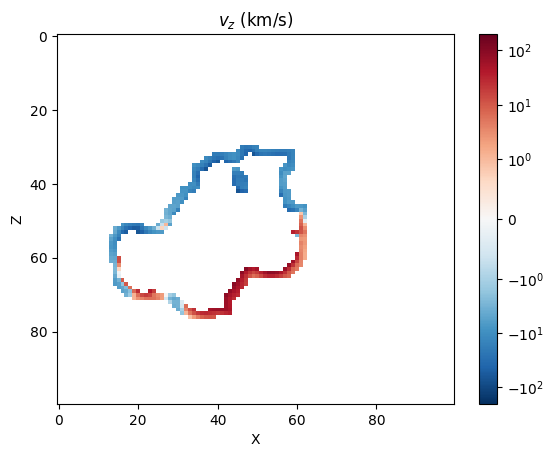

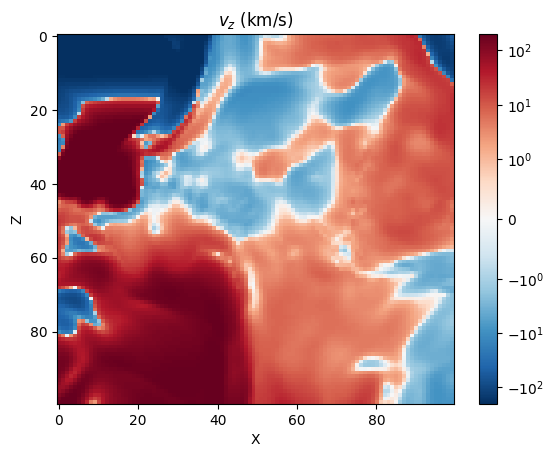

In [39]:
# read density slice
lower_b = 20
upper_b = 80
input_point = (center_x, center_z)
mask = np.zeros((100, upper_b - lower_b, 100))
dilated_stack = np.zeros((100, upper_b - lower_b, 100))

for current_y in range(upper_b - lower_b):
    dens_slice = normalize4thresholding(new_dens[:, current_y + lower_b, :]) 

    # cv2.imwrite(f"tmp/dens_{current_z}.png", dens_slice)
    # dens_img = cv2.imread(f"tmp/dens_{current_z}.png")
    
    # threshold + connected component
    binary_mask = apply_otsus_thresholding(dens_slice)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

    # Check each component's bounding box to find the target mask
    for i in range(3, num_labels):  # Starting from 1 to ignore the background
        x, y, w, h, area = stats[i]
        
        # Check if the center point is within the bounding box
        if SN_center_in_bubble(input_point[0], input_point[1], x, y, w, h):     # and area < 10 * 427
            # If yes, fill the target_mask with this component
            binary_mask = labels == i
            
            # Save the target mask
            mask[:, current_y, :] = binary_mask
            target_mask = np.where(labels == i, 255, 0).astype('uint8')

            break 


    # dilate the binary mask for 3 pixels
    kernel = np.ones((5, 5), np.uint8)
    
    # outside mask
    dilated_mask = cv2.dilate(target_mask, kernel, iterations=1)
    dilated_stack[:, current_y, :] = dilated_mask

    # subtract the dilated mask with the original binary mask to retrieve the boundary edge for the sphere
boundary_edge = np.logical_xor(mask, dilated_stack).astype(float)

# cast the ring of mask over velz and dens array, plot out the velocity profile, with integrated density as a function of velz  
velz_roi = np.where(boundary_edge, new_velz[:, lower_b:upper_b, :], np.nan)
dens_roi = np.where(boundary_edge, new_dens[:, lower_b:upper_b, :], np.nan)

# plt.plot(velz_roi[:, center_y, 25].T)
plt.imshow(velz_roi[:, 20, :].T[::], cmap='RdBu_r', aspect='auto',
                norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
plt.colorbar()

plt.title('$v_z$ (km/s)')
plt.xlabel('X')
plt.ylabel('Z')
# plt.savefig(f'graphs/{time_Myr}/ringed_velz_{center_z}.png')
plt.show()

plt.imshow(new_velz[:, 20, :].T[::], cmap='RdBu_r', aspect='auto',
                norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
plt.colorbar()

plt.title('$v_z$ (km/s)')
plt.xlabel('X')
plt.ylabel('Z')
# plt.savefig(f'graphs/{time_Myr}/ringed_velz_{center_z}.png')
plt.show()



In [31]:
# organized the ring mask coordinates into dictionary, one slice per record

ringed_stack = {}

for z in range(upper_b - lower_b):
    ringed_mask = {'coord_x': [], 'coord_y': [],'velz': [], 'dens': []}
    binary_mask = boundary_edge[:, :, z]
    coords = np.where(binary_mask == 1)

 
    # coords = np.column_stack(np.where(binary_mask == 1))

    velz_values = velz_roi[coords[0], coords[1], z + lower_b]
    dens_values = dens_roi[coords[0], coords[1], z + lower_b]

    # print(coords[0].size)


    ringed_mask['coord_x'].extend(coords[0].tolist())
    ringed_mask['coord_y'].extend(coords[1].tolist())
    
    ringed_mask['velz'].extend(velz_values.tolist())
    ringed_mask['dens'].extend(dens_values.tolist())

    ringed_stack[z] = ringed_mask

In [88]:
np.max(mask[10])

0.0

In [19]:
len(ringed_stack[0]['coord_z'])

KeyError: 'coord_z'

Text(0.5, 1.0, 'ring mask')

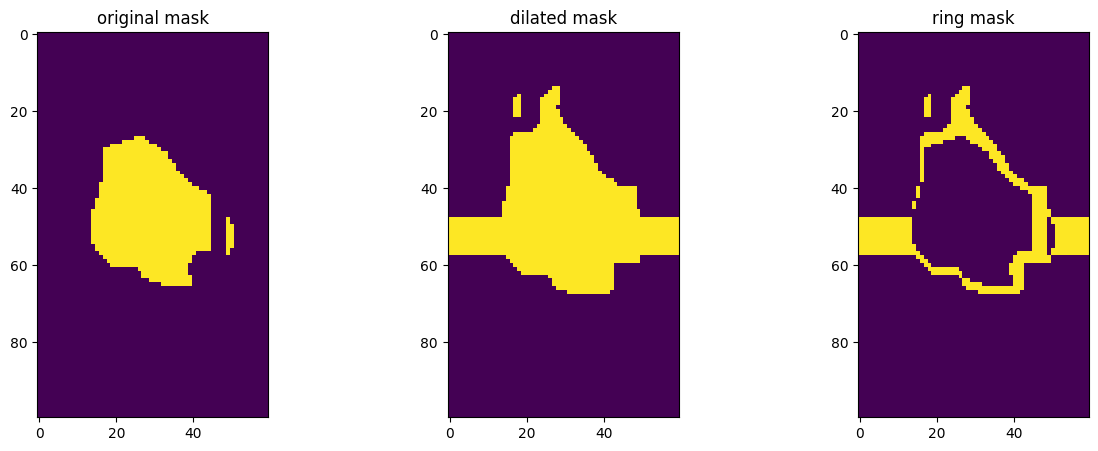

In [32]:
f = plt.figure(figsize=(15, 5))
ax = f.add_subplot(131)
ax2 = f.add_subplot(132)
ax3 = f.add_subplot(133)

mask_z = 50
ax.imshow(mask[:, :, mask_z])
ax.set_title("original mask")
ax2.imshow(dilated_stack[:, :, mask_z])
ax2.set_title("dilated mask")
ax3.imshow(boundary_edge[:, :, mask_z])
ax3.set_title("ring mask")


## X-Y plane velocity

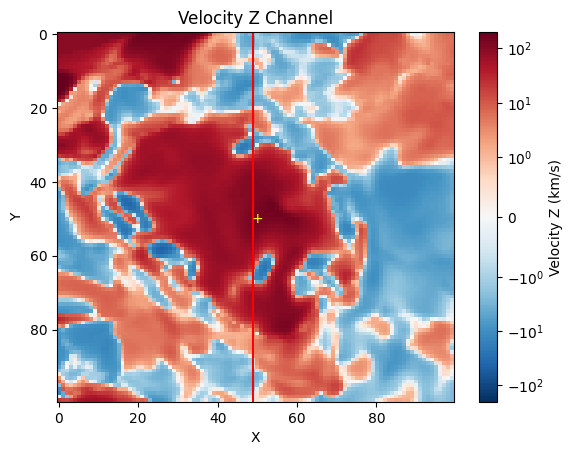

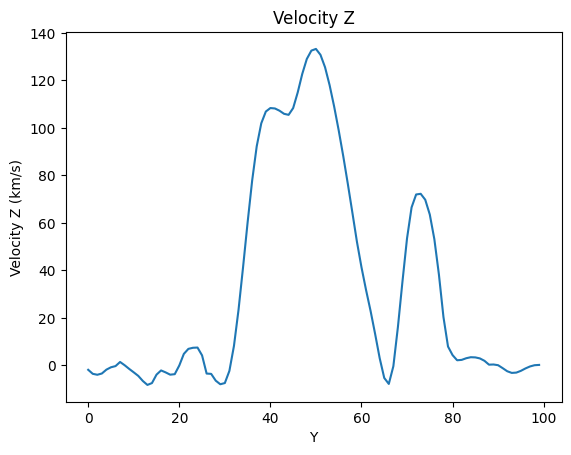

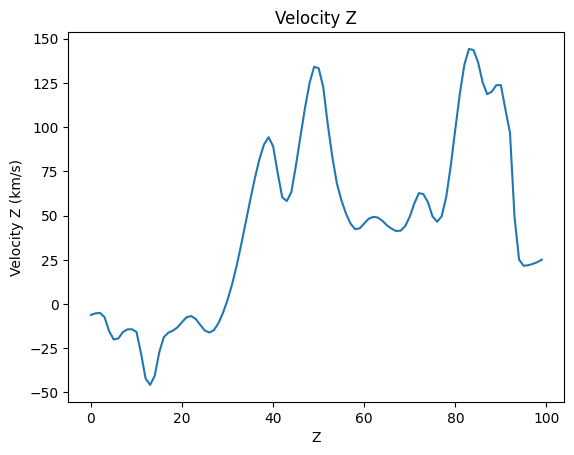

In [215]:
# Velocity slice, log scaled
fig, ax = plt.subplots()
#im = ax.imshow((np.log(new_velz[:, :, center_z].T[::])), cmap='RdBu', aspect='auto')
im = ax.imshow(new_velz[:, :, center_z].T[::], cmap='RdBu_r', aspect='auto',
                norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
ax.annotate("+", xy=(50, 50), color="yellow", ha="center", va="center")
fig.colorbar(im, label='Velocity Z (km/s)')

# labelling the line of sight profile
plt.axvline(center_x, color='r')

plt.title('Velocity Z Channel')
plt.xlabel('X')
plt.ylabel('Y')
fig.savefig(f'../expanding_velocity/{time_Myr}/vzoom_velz_cenz_{center_z}.png')
plt.show()

# LoS: y line
plt.plot(new_velz[center_x, :, center_z].T[::])


plt.title('Velocity Z')
plt.xlabel('Y')
plt.ylabel('Velocity Z (km/s)')
plt.savefig(f'../expanding_velocity/{time_Myr}/LOS_velz_y_{center_x}.png')
plt.show()


# LoS velz: z line
plt.plot(new_velz[center_x, center_y, :].T[::])

plt.title('Velocity Z')
plt.xlabel('Z')
plt.ylabel('Velocity Z (km/s)')
plt.savefig(f'../expanding_velocity/{time_Myr}/LOS_velz_z_{center_z}.png')
plt.show()

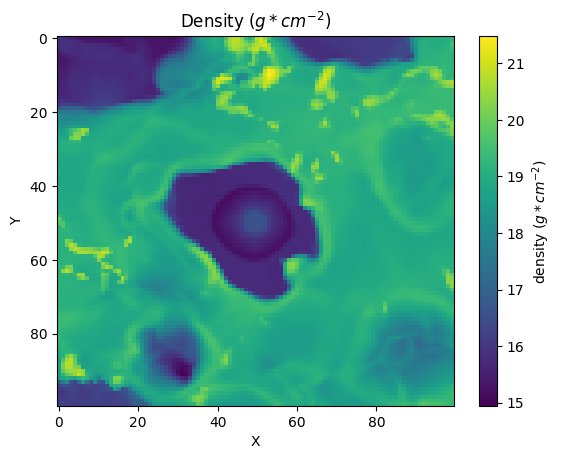

In [62]:
# Density zoom in

fig, ax = plt.subplots()
im = ax.imshow(np.log10(new_dens[:, :, center_z].T[::]), cmap='viridis', aspect='auto')
fig.colorbar(im, label='density ($g*cm^{-2}$)')
plt.title('Density ($g*cm^{-2}$)')
plt.xlabel('X')
plt.ylabel('Y')
# fig.savefig(f'../expanding_velocity/{time_Myr}/dzoom_{center_z}.png')
plt.show()


## Mass Flux 
- x-y plane

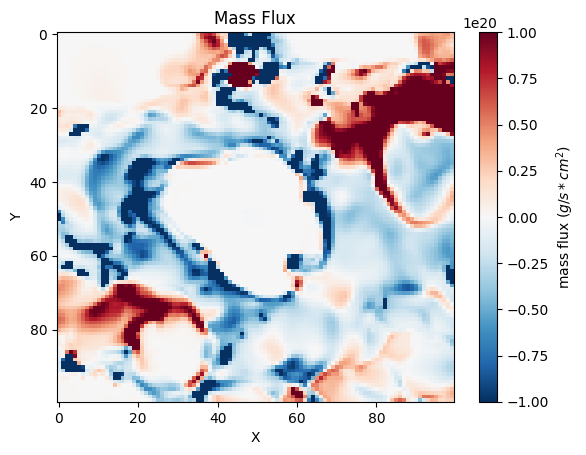

In [57]:
# velz * dens -> mass flux
import yt.config


fig, ax = plt.subplots()
#im = ax.imshow((np.log(new_velz[:, :, center_z].T[::])), cmap='RdBu', aspect='auto')
mass_flux = new_velz * new_dens
im = ax.imshow((mass_flux[:, :, center_z].T[::]), cmap='RdBu_r', aspect='auto',
               vmin=-1e20, vmax=1e20)#
                #norm=colors.SymLogNorm(linthresh=1))#, vmin=-200, vmax=200))
fig.colorbar(im, label='mass flux ($g/s * cm^2$)')

plt.title('Mass Flux')
plt.xlabel('X')
plt.ylabel('Y')
fig.savefig(f'../expanding_velocity/{time_Myr}/mass_flux_cenz_{center_z}.png')
plt.show()

## Line Of Sight Velocity
- x-y plane

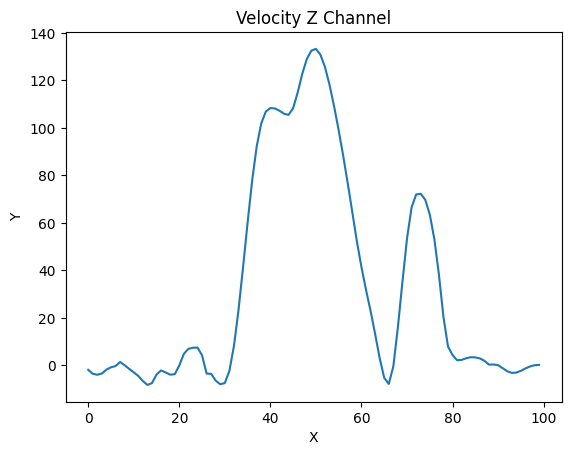

In [225]:
# Velocity slice, log scaled
fig, ax = plt.subplots()
#im = ax.imshow((np.log(new_velz[:, :, center_z].T[::])), cmap='RdBu', aspect='auto')
# im = ax.imshow(new_velz[center_x, :, center_z].T[::], cmap='RdBu_r', aspect='auto',
#                 norm=colors.SymLogNorm(linthresh=1, vmin=-200, vmax=200))
# fig.colorbar(im, label='Velocity Z (km/s)')


plt.plot(new_velz[center_x, :, center_z].T[::])

plt.title('Velocity Z Channel')
plt.xlabel('X')
plt.ylabel('Y')
# fig.savefig(f'../expanding_velocity/{time_Myr}/LOS_cenz{center_z}.png')
plt.show()

## Dens - Velz
- integrated density as a function of velz
- extracting line of sight (center_x, center_y, 25:75)
- perpendicular to x-y plane, at the center of SN explosion.

In [33]:
# integrating all velz and dens in the ring masks
velz_acc = []
dens_acc = []

for z in range(upper_b - lower_b):
    velz_acc.extend(ringed_stack[z]['velz'])
    dens_acc.extend(ringed_stack[z]['dens'])


In [35]:
# at center coordinates

LoS_velz = velz_acc #velz_roi #new_velz[center_x, center_y, 25:75].T[::]
LoS_coldens = dens_acc # dens_roi #new_dens[center_x, center_y, 25:75].T[::]

print(np.min(LoS_velz))
print(np.max(LoS_velz))

sortidx = np.argsort(LoS_velz)
sorted_velz = np.array(LoS_velz)[sortidx]
sorted_dens = np.array(LoS_coldens)[sortidx]

bins = np.linspace(int(sorted_velz.min()), int(sorted_velz.max()), 500)  # 21 bins means 22 edges
bin_centers = 0.5 * (bins[:-1] + bins[1:])  # Calculate bin centers for plotting

indices = np.digitize(sorted_velz, bins)

binned_densities = np.zeros(len(bins)-1)
for i in range(1, len(bins)):
    binned_densities[i-1] = sorted_dens[indices == i].sum()

fig, ax = plt.subplots()
ax.bar(bin_centers, binned_densities, width=np.diff(bins), edgecolor='black', align='center')
ax.set_xlabel('velz ($km/s$)')
ax.set_ylabel('Integrated density ($g/cm^2$)')
ax.set_title('Shockwave edge $v_z$')
ax.set_yscale('log')
# ax.set_xlim(-200, 200)
# plt.savefig("LoS.png")


# fig, ax = plt.subplots()
# ax.plot(sorted_velz, sorted_dens, 'k-')
# ax.set_xlabel('$v_z$')
# ax.set_ylabel('column density (cm$^{-2}$)')
# ax.set_xlim(-7.5, 0)
# # ax.set_yscale('log')

# fig.savefig('dens_velz.png')





nan
nan


ValueError: cannot convert float NaN to integer

18.597476187404357
99.70523998141377


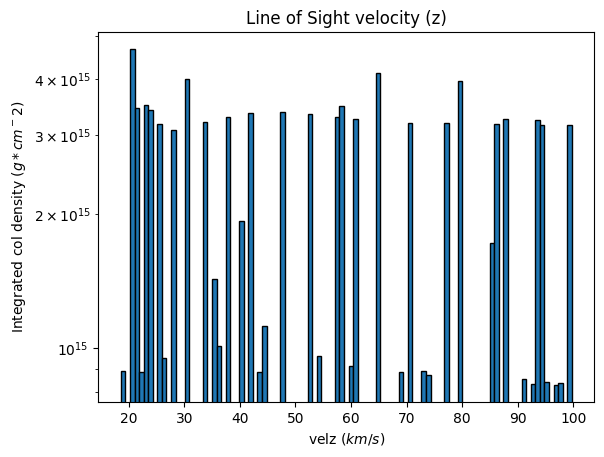

In [228]:
LoS_velz = new_velz[30, center_y, 25:75].T[::]
LoS_coldens = new_dens[30, center_y, 25:75].T[::]

print(np.min(LoS_velz))
print(np.max(LoS_velz))

sortidx = np.argsort(LoS_velz)
sorted_velz = LoS_velz[sortidx]
sorted_dens = LoS_coldens[sortidx]

bins = np.linspace(sorted_velz.min(), sorted_velz.max(), 100)  # 21 bins means 22 edges
bin_centers = 0.5 * (bins[:-1] + bins[1:])  # Calculate bin centers for plotting

indices = np.digitize(sorted_velz, bins)

binned_densities = np.zeros(len(bins)-1)
for i in range(1, len(bins)):
    binned_densities[i-1] = sorted_dens[indices == i].sum()

fig, ax = plt.subplots()
ax.bar(bin_centers, binned_densities, width=np.diff(bins), edgecolor='black', align='center')
ax.set_xlabel('velz ($km/s$)')
ax.set_ylabel('Integrated col density ($g*cm^-2$)')
ax.set_title('Line of Sight velocity (z)')
ax.set_yscale('log')

## LoS v_z and density line plots
- $v_z$ and density as a function of z coordinate (bottom to top, 30:60)
- trying to find the bubble edge, expansion velocity, and how to visualize them

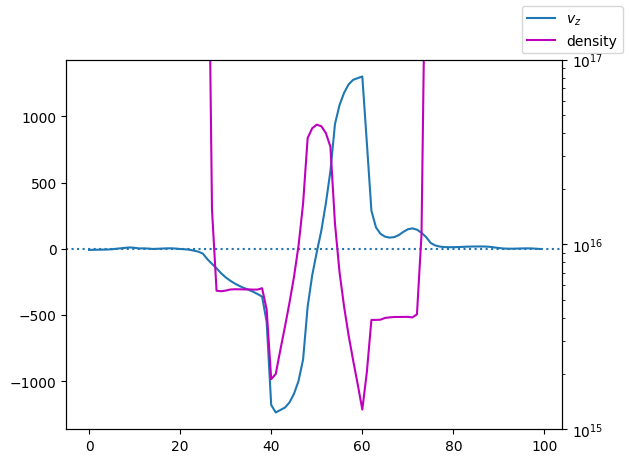

In [98]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(new_velz[center_x, center_y, lower_b:upper_b].T[::],
        label='$v_z$')
ax.axhline(y=0, linestyle=':')
# ax.legend()
axr = ax.twinx()
axr.plot(new_dens[center_x, center_y, lower_b:upper_b].T[::], 'm',
         label='density')
# axr.legend()
axr.set_yscale('log')
axr.set_ylim(1e15,1e17)

fig.legend()

## velz - dens scatter plot
- did it on 210 Myr, shows a perfect circle! which means we found the momentum conservation phase, so the lower the density, the higher the velocity. 
- but we were hoping to see some signature at the bubble edge, to see if we can visualize the expansion

Text(0.5, 1.0, 'y = full stack')

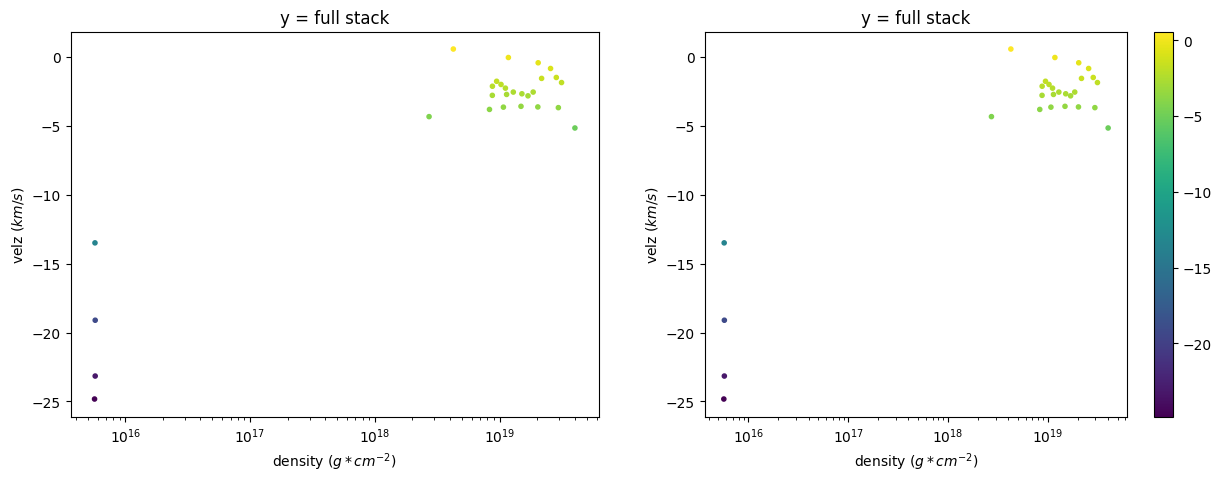

In [36]:
f = plt.figure(figsize=(15, 5))
ax = f.add_subplot(121)
ax2 = f.add_subplot(122)

# with lower and upper boundaries
# lower_b = 25
# upper_b = 75
# LoS_velz = new_velz[center_x, center_y, lower_b:upper_b].T[::]
# LoS_coldens = new_dens[center_x, center_y, lower_b:upper_b].T[::]
LoS_velz = velz_roi[center_x, :, center_z ].T[::]
LoS_coldens = dens_roi[center_x, :, center_z ].T[::]


im1 = ax.scatter(LoS_coldens, LoS_velz, marker=".", c = LoS_velz, cmap="viridis")
# f.colorbar(im1)
ax.set_xscale('log')
ax.set_xlabel('density ($g*cm^{-2}$)')
ax.set_ylabel('velz ($km/s$)')
# ax.set_xlim((1e15, 1e16))
ax.set_title('y = full stack')


# slicing the middle portion

lower_b = 0
upper_b = 100

LoS_velz = velz_roi[center_x, lower_b:upper_b, center_y].T[::]
LoS_coldens = dens_roi[center_x, lower_b:upper_b, center_y].T[::]

# plt.subplot(1, 2, 2)
im2 = ax2.scatter(LoS_coldens, LoS_velz, marker=".", c = LoS_velz, cmap="viridis")
f.colorbar(im2)
ax2.set_xscale('log')
ax2.set_xlabel('density ($g*cm^{-2}$)')
ax2.set_ylabel('velz ($km/s$)')
# ax2.set_xlim((1e15, 1e16))
ax2.set_title('y = full stack')
